# .mat 파일 내용 확인
- Ray Tracing 결과로 저장된 multipath 파라미터 시각화
- `scenarios/DT31/wireless/scene_{N}/BS1_UE_0-1.mat` 기준

| Row | 파라미터 | 단위 |
|-----|----------|------|
| 0 | Phase | deg |
| 1 | ToA (delay) | s |
| 2 | Rx Power | dBm |
| 3 | DoA azimuth (phi) | deg |
| 4 | DoA elevation (theta) | deg |
| 5 | DoD azimuth (phi) | deg |
| 6 | DoD elevation (theta) | deg |
| 7 | LoS flag | 0/1 |
| 8 | Doppler velocity | m/s |
| 9 | Doppler acceleration | m/s² |

In [1]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── 파일 경로 설정 ─────────────────────────────────────────────
SCENE_IDX = 0
MAT_PATH  = f"scenarios/DT31/wireless/scene_{SCENE_IDX}/BS1_UE_0-1.mat"

mat = sio.loadmat(MAT_PATH)
p   = mat["channels"][0, 0]["p"][0, 0]   # (10, P)
P   = p.shape[1]

# Row 의미 매핑 (RayTracingLoader.py 기준)
ROW_NAMES = {
    0: ("Phase",             "deg"),
    1: ("ToA (delay)",       "s"),
    2: ("Rx Power",          "dBm"),
    3: ("DoA azimuth",       "deg"),
    4: ("DoA elevation",     "deg"),
    5: ("DoD azimuth",       "deg"),
    6: ("DoD elevation",     "deg"),
    7: ("LoS flag",          "0/1"),
    8: ("Doppler vel",       "m/s"),
    9: ("Doppler acc",       "m/s²"),
}

# ── 기본 정보 출력 ─────────────────────────────────────────────
print("=" * 55)
print(f"  Scene {SCENE_IDX}  |  {MAT_PATH}")
print("=" * 55)

tx = mat["tx_loc"].squeeze()
rx = mat["rx_locs"].squeeze()
print(f"  BS 위치  (x, y, z) : {tx[0]:.2f}, {tx[1]:.2f}, {tx[2]:.2f}")
print(f"  UE 위치  (x, y, z) : {rx[0]:.2f}, {rx[1]:.2f}, {rx[2]:.2f}")
print(f"  BS-UE 거리          : {rx[3]:.2f} m")
print(f"  Path Loss           : {rx[4]:.2f} dB")
print(f"  총 multipath 수     : {P}")
print(f"  LoS 경로 수         : {int(p[7].sum())}")
print()
print(f"  {chr(34)}Row{chr(34):<4} {chr(34)}파라미터{chr(34):<20} {chr(34)}단위{chr(34):<8} {chr(34)}min{chr(34):>12} {chr(34)}max{chr(34):>12} {chr(34)}mean{chr(34):>12}")
print("  " + "-" * 72)
for i in range(10):
    name, unit = ROW_NAMES[i]
    v = p[i]
    print(f"  {i:<5} {name:<22} {unit:<8} {v.min():>12.4g} {v.max():>12.4g} {v.mean():>12.4g}")


  Scene 0  |  scenarios/DT31/wireless/scene_0/BS1_UE_0-1.mat
  BS 위치  (x, y, z) : -57.77, 96.14, 3.45
  UE 위치  (x, y, z) : -44.69, 94.32, 1.68
  BS-UE 거리          : 13.32 m
  Path Loss           : 90.05 dB
  총 multipath 수     : 814
  LoS 경로 수         : 1

  "Row"    "파라미터"                    "단위"        "min           " "max           " "mean           "
  ------------------------------------------------------------------------
  0     Phase                  deg            -179.8        179.4        4.103
  1     ToA (delay)            s           4.446e-08    2.763e-06    9.059e-07
  2     Rx Power               dBm            -214.2       -90.69       -168.1
  3     DoA azimuth            deg              -177        176.3       -15.34
  4     DoA elevation          deg             73.16        122.5        87.67
  5     DoD azimuth            deg            -176.3        176.2       -20.49
  6     DoD elevation          deg             78.97        108.7        91.82
  7     LoS fla

## 각 Row 상위 5개 값 확인

In [2]:
print(f"총 경로 수: {P}개\n")
print(f"{'Row':<5} {'파라미터':<22} {'단위':<8}  상위 5개 값")
print("-" * 100)
for i in range(10):
    name, unit = ROW_NAMES[i]
    v = p[i]
    if i == 7:  # LoS flag는 앞 5개
        top5 = v[:5]
        label = "(first 5)"
    else:
        top5 = np.sort(v)[::-1][:5]
        label = "(내림차순)"
    vals_str = "  ".join(f"{x:>13.5g}" for x in top5)
    print(f"{i:<5} {name:<22} {unit:<8}  {vals_str}  {label}")


총 경로 수: 814개

Row   파라미터                   단위        상위 5개 값
----------------------------------------------------------------------------------------------------
0     Phase                  deg              179.35         179.15         179.06         178.46         178.32  (내림차순)
1     ToA (delay)            s            2.7634e-06     2.5555e-06     2.5176e-06     2.4871e-06     2.4274e-06  (내림차순)
2     Rx Power               dBm             -90.695        -107.57         -114.6         -120.8        -121.97  (내림차순)
3     DoA azimuth            deg              176.26         176.11         176.06          175.9          175.9  (내림차순)
4     DoA elevation          deg               122.5         113.71         100.63         99.997         97.201  (내림차순)
5     DoD azimuth            deg              176.17         176.15         175.92         175.91         175.52  (내림차순)
6     DoD elevation          deg               108.7         107.94         107.93         106.63         106.15

## 히스토그램 분포 시각화

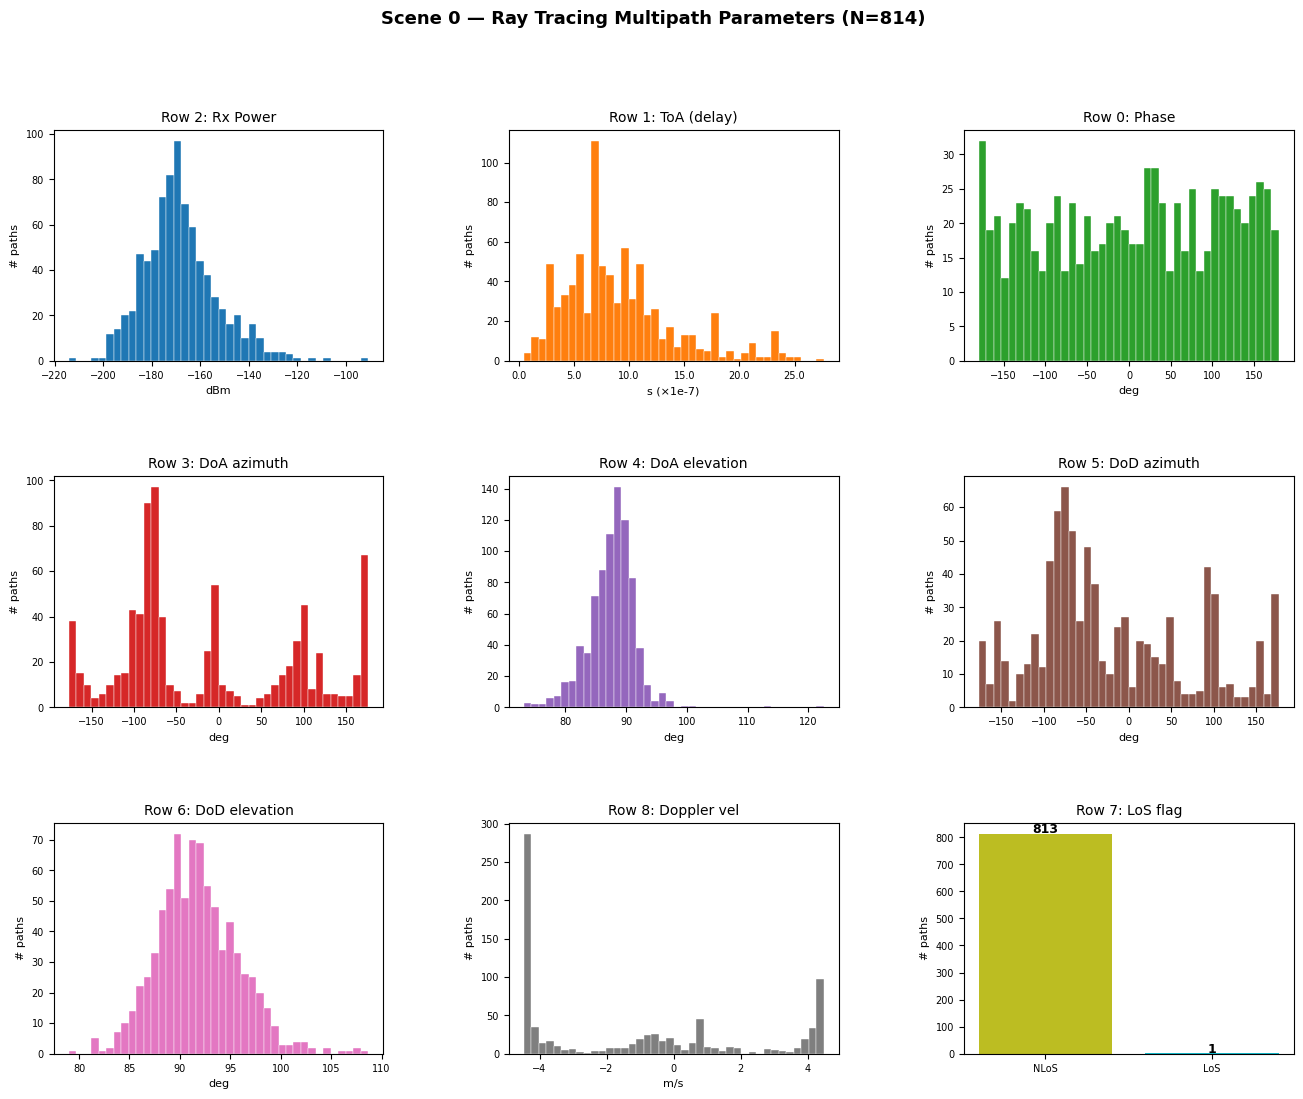

In [3]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle(f"Scene {SCENE_IDX} — Ray Tracing Multipath Parameters (N={P})", fontsize=13, fontweight="bold")
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)
colors = plt.cm.tab10.colors

def hist_ax(ax, row, bins=40, color="steelblue"):
    name, unit = ROW_NAMES[row]
    ax.hist(p[row], bins=bins, color=color, edgecolor="white", linewidth=0.3)
    ax.set_title(f"Row {row}: {name}", fontsize=10)
    ax.set_xlabel(unit, fontsize=8)
    ax.set_ylabel("# paths", fontsize=8)
    ax.tick_params(labelsize=7)

# Row 2: Rx Power
hist_ax(fig.add_subplot(gs[0, 0]), 2, color=colors[0])

# Row 1: ToA (x축 단위 변환)
ax = fig.add_subplot(gs[0, 1])
hist_ax(ax, 1, color=colors[1])
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*1e7:.1f}"))
ax.set_xlabel("s (×1e-7)", fontsize=8)

# Row 0: Phase
hist_ax(fig.add_subplot(gs[0, 2]), 0, color=colors[2])

# Row 3: DoA azimuth
hist_ax(fig.add_subplot(gs[1, 0]), 3, color=colors[3])

# Row 4: DoA elevation
hist_ax(fig.add_subplot(gs[1, 1]), 4, color=colors[4])

# Row 5: DoD azimuth
hist_ax(fig.add_subplot(gs[1, 2]), 5, color=colors[5])

# Row 6: DoD elevation
hist_ax(fig.add_subplot(gs[2, 0]), 6, color=colors[6])

# Row 8: Doppler velocity
hist_ax(fig.add_subplot(gs[2, 1]), 8, color=colors[7])

# Row 7: LoS flag (bar chart)
ax = fig.add_subplot(gs[2, 2])
los_counts = [int((p[7] == 0).sum()), int((p[7] == 1).sum())]
ax.bar(["NLoS", "LoS"], los_counts, color=[colors[8], colors[9]])
ax.set_title("Row 7: LoS flag", fontsize=10)
ax.set_ylabel("# paths", fontsize=8)
ax.tick_params(labelsize=7)
for k, v in enumerate(los_counts):
    ax.text(k, v + 2, str(v), ha="center", fontsize=9, fontweight="bold")

plt.savefig(f"scene{SCENE_IDX}_multipath_hist.png", dpi=120, bbox_inches="tight")
plt.show()


## Power 상위 25개 path 파라미터 분포 (전체와 비교)

In [ ]:
TOP_K = 25
top_idx = np.argsort(p[2])[::-1][:TOP_K]  # Row 2: Rx Power (dBm), 값이 클수록 강한 path
p_top = p[:, top_idx]
P_top = p_top.shape[1]

print(f"All paths      : {P}")
print(f"Top-{TOP_K} paths : {P_top}")
print(f"Selected power range : {p_top[2].min():.3f} ~ {p_top[2].max():.3f} dBm")
print(f"Top-{TOP_K} LoS paths : {int(p_top[7].sum())}")

fig = plt.figure(figsize=(16, 12))
fig.suptitle(f"Scene {SCENE_IDX} — Top-{TOP_K} Strongest Paths by Rx Power", fontsize=13, fontweight="bold")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.40)
colors = plt.cm.tab10.colors

def hist_compare_ax(ax, row, bins=25, color="steelblue"):
    name, unit = ROW_NAMES[row]
    all_vals = p[row].copy()
    top_vals = p_top[row].copy()

    if row == 1:
        all_vals = all_vals * 1e9
        top_vals = top_vals * 1e9
        xlabel = "ToA (ns)"
    else:
        xlabel = unit

    bin_edges = np.histogram_bin_edges(all_vals, bins=bins)
    ax.hist(all_vals, bins=bin_edges, density=True, alpha=0.30,
            color="lightgray", edgecolor="white", linewidth=0.3,
            label=f"All ({P})")
    ax.hist(top_vals, bins=bin_edges, density=True, alpha=0.85,
            color=color, edgecolor="white", linewidth=0.3,
            label=f"Top-{P_top}")
    ax.set_title(f"Row {row}: {name}", fontsize=10)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel("density", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2)

hist_compare_ax(fig.add_subplot(gs[0, 0]), 2, color=colors[0])
hist_compare_ax(fig.add_subplot(gs[0, 1]), 1, color=colors[1])
hist_compare_ax(fig.add_subplot(gs[0, 2]), 0, color=colors[2])
hist_compare_ax(fig.add_subplot(gs[1, 0]), 3, color=colors[3])
hist_compare_ax(fig.add_subplot(gs[1, 1]), 4, color=colors[4])
hist_compare_ax(fig.add_subplot(gs[1, 2]), 5, color=colors[5])
hist_compare_ax(fig.add_subplot(gs[2, 0]), 6, color=colors[6])
hist_compare_ax(fig.add_subplot(gs[2, 1]), 8, color=colors[7])

ax = fig.add_subplot(gs[2, 2])
labels = ["NLoS", "LoS"]
x = np.arange(len(labels))
width = 0.35
all_ratio = np.array([(p[7] == 0).sum(), (p[7] == 1).sum()]) / P
top_ratio = np.array([(p_top[7] == 0).sum(), (p_top[7] == 1).sum()]) / P_top
ax.bar(x - width/2, all_ratio, width, color="lightgray", label=f"All ({P})")
ax.bar(x + width/2, top_ratio, width, color="tomato", label=f"Top-{P_top}")
ax.set_xticks(x, labels)
ax.set_ylim(0, 1.0)
ax.set_title("Row 7: LoS flag", fontsize=10)
ax.set_ylabel("ratio", fontsize=8)
ax.tick_params(labelsize=7)
ax.legend(fontsize=7)
ax.grid(True, axis="y", alpha=0.2)

plt.savefig(f"scene{SCENE_IDX}_top{TOP_K}_multipath_compare.png", dpi=120, bbox_inches="tight")
plt.show()


## Power Delay Profile (PDP) — ToA vs Rx Power

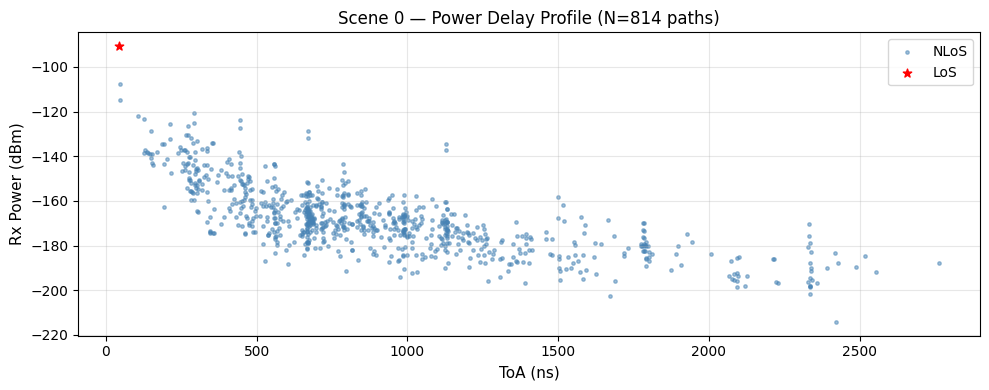

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))

toa   = p[1]          # Row 1: ToA (s)
power = p[2]          # Row 2: Rx Power (dBm)
los   = p[7].astype(bool)

# NLOS 먼저, LOS 위에 덮어씌움
ax.scatter(toa[~los] * 1e9, power[~los], s=6, alpha=0.5, color="steelblue", label="NLoS")
ax.scatter(toa[los]  * 1e9, power[los],  s=40, marker="*", color="red",       label="LoS")

ax.set_xlabel("ToA (ns)", fontsize=11)
ax.set_ylabel("Rx Power (dBm)", fontsize=11)
ax.set_title(f"Scene {SCENE_IDX} — Power Delay Profile (N={P} paths)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"scene{SCENE_IDX}_pdp.png", dpi=120, bbox_inches="tight")
plt.show()


## DoA / DoD 산점도 (Azimuth vs Elevation)

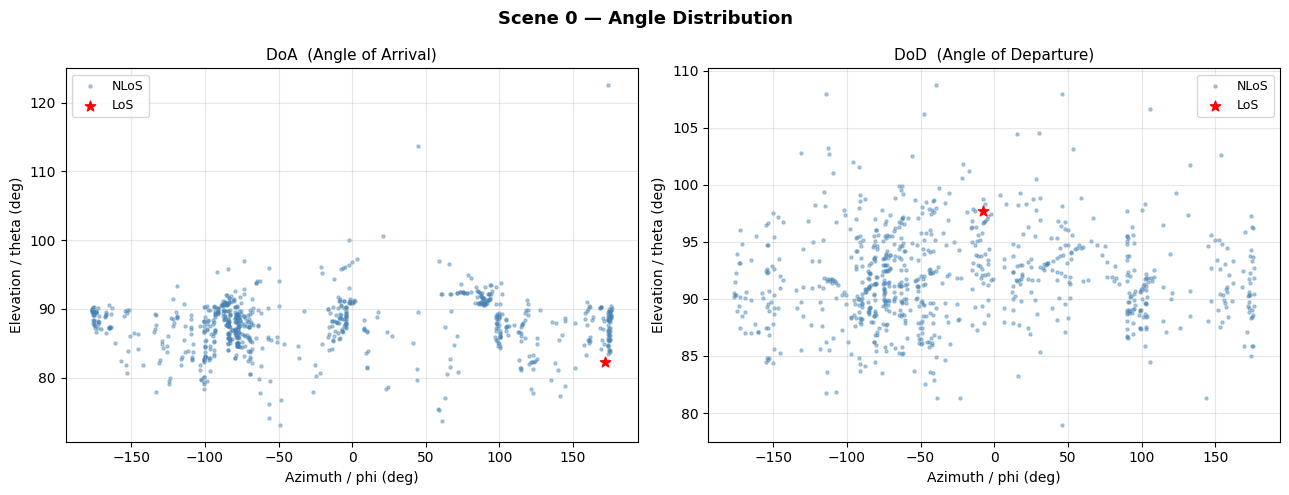

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Scene {SCENE_IDX} — Angle Distribution", fontsize=13, fontweight="bold")

los = p[7].astype(bool)

for ax, (phi_row, theta_row, title) in zip(axes, [
    (3, 4, "DoA  (Angle of Arrival)"),
    (5, 6, "DoD  (Angle of Departure)"),
]):
    phi   = p[phi_row]
    theta = p[theta_row]
    sc = ax.scatter(phi[~los], theta[~los], s=5, alpha=0.4, c="steelblue", label="NLoS")
    ax.scatter(phi[los], theta[los], s=60, marker="*", c="red", label="LoS", zorder=5)
    ax.set_xlabel("Azimuth / phi (deg)", fontsize=10)
    ax.set_ylabel("Elevation / theta (deg)", fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"scene{SCENE_IDX}_angles.png", dpi=120, bbox_inches="tight")
plt.show()


## Doppler velocity 분포 (LoS vs NLoS)

/tmp/ipykernel_663180/1912135946.py:15: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_663180/1912135946.py:16: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.savefig(f"scene{SCENE_IDX}_doppler.png", dpi=120, bbox_inches="tight")
/home/dlghdbs200/anaconda3/envs/hoyun_312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


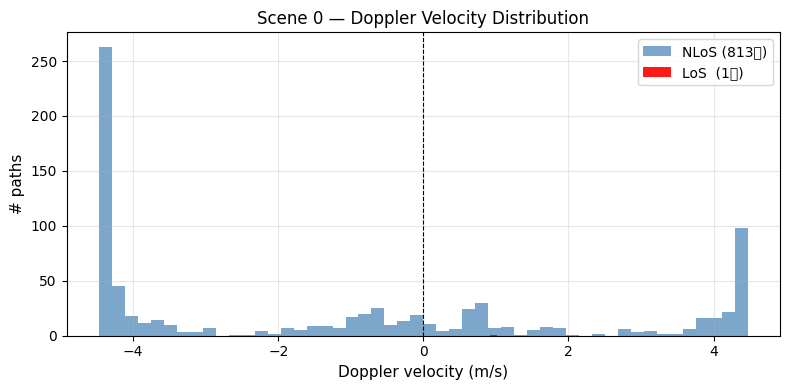

LoS  Doppler vel : 0.9143 m/s (mean)
NLoS Doppler vel : -1.1067 m/s (mean)


In [6]:
fig, ax = plt.subplots(figsize=(8, 4))

dop = p[8]   # Row 8: Doppler velocity
los = p[7].astype(bool)

ax.hist(dop[~los], bins=50, alpha=0.7, color="steelblue", label=f"NLoS ({(~los).sum()}개)")
ax.hist(dop[los],  bins=10, alpha=0.9, color="red",       label=f"LoS  ({los.sum()}개)")
ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Doppler velocity (m/s)", fontsize=11)
ax.set_ylabel("# paths", fontsize=11)
ax.set_title(f"Scene {SCENE_IDX} — Doppler Velocity Distribution", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"scene{SCENE_IDX}_doppler.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"LoS  Doppler vel : {dop[los].mean():.4f} m/s (mean)")
print(f"NLoS Doppler vel : {dop[~los].mean():.4f} m/s (mean)")


Total scenes      : 7012
First scene time  : 0.0000 s
Last scene time   : 3136.5391 s  (52.3 min)

Interval statistics (ms)
  Min    : 0.00 ms
  Max    : 437673.40 ms
  Mean   : 447.37 ms
  Median : 92.07 ms
  80~110ms ratio : 88.8%  <- normal sampling range

Gaps >= 500ms : 52 found
    scene from   scene to    gap (s)
  -----------------------------------
            91         92       30.4s
           372        373       31.0s
           474        475       92.2s
           681        682       26.6s
           769        770       31.1s
           987        988       46.0s
          1053       1054       66.0s
          1144       1145       27.8s
          1317       1318       27.0s
          1398       1399       19.6s
          1532       1533       75.4s
          1697       1698       26.0s
          1785       1786       23.8s
          1944       1945       30.3s
          2035       2036       16.0s
          2196       2197       25.3s
          2295       2296       

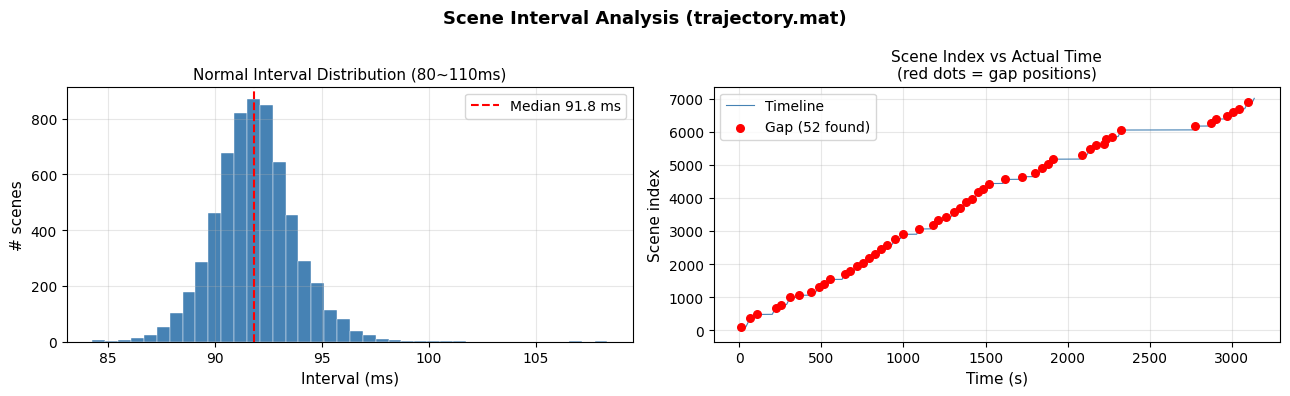

In [17]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

mat    = sio.loadmat("scenarios/DT31/param/trajectory.mat")
scenes = mat["scene"][0]
times  = np.array([float(scenes[i]["time"][0,0][0,0]) for i in range(len(scenes))])
diffs  = np.diff(times) * 1000  # ms

# ── Basic Statistics ───────────────────────────────────────────
print(f"Total scenes      : {len(times)}")
print(f"First scene time  : {times[0]:.4f} s")
print(f"Last scene time   : {times[-1]:.4f} s  ({(times[-1]-times[0])/60:.1f} min)")
print()
print(f"Interval statistics (ms)")
print(f"  Min    : {diffs.min():.2f} ms")
print(f"  Max    : {diffs.max():.2f} ms")
print(f"  Mean   : {diffs.mean():.2f} ms")
print(f"  Median : {np.median(diffs):.2f} ms")
print(f"  80~110ms ratio : {((diffs>=80)&(diffs<=110)).mean()*100:.1f}%  <- normal sampling range")
print()

# Large gaps (>= 500ms)
big_idx = np.where(diffs > 500)[0]
print(f"Gaps >= 500ms : {len(big_idx)} found")
print(f"  {'scene from':>12} {'scene to':>10} {'gap (s)':>10}")
print(f"  {'-'*35}")
for i in big_idx:
    print(f"  {i:>12d} {i+1:>10d} {diffs[i]/1000:>10.1f}s")

# ── Visualization ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Scene Interval Analysis (trajectory.mat)", fontsize=13, fontweight="bold")

# Left: histogram of normal intervals
normal = diffs[(diffs >= 80) & (diffs <= 110)]
axes[0].hist(normal, bins=40, color="steelblue", edgecolor="white", linewidth=0.3)
axes[0].axvline(np.median(normal), color="red", linestyle="--", linewidth=1.5,
                label=f"Median {np.median(normal):.1f} ms")
axes[0].set_xlabel("Interval (ms)", fontsize=11)
axes[0].set_ylabel("# scenes", fontsize=11)
axes[0].set_title("Normal Interval Distribution (80~110ms)", fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: 전체를 하나의 선으로 연결 + gap 위치에 빨간 점
ax = axes[1]
ax.plot(times, np.arange(len(times)), color="steelblue", linewidth=0.8, label="Timeline")
ax.scatter(times[big_idx], big_idx, color="red", s=30, zorder=5, label=f"Gap ({len(big_idx)} found)")

ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Scene index", fontsize=11)
ax.set_title("Scene Index vs Actual Time\n(red dots = gap positions)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("scene_time_interval.png", dpi=120, bbox_inches="tight")
plt.show()

## Scene 간 시간 간격 분석 (trajectory.mat)

In [18]:
# ── ~95ms 인터벌 장면 찾기 ─────────────────────────────────────
tol = 2.5  # ±2.5ms  →  92.5 ~ 97.5ms
mask = (diffs >= 95 - tol) & (diffs <= 95 + tol)
idx_95 = np.where(mask)[0]

print(f"약 95ms 인터벌 장면 (92.5~97.5ms): {len(idx_95)}개")
print(f"  {'from_scene':>12} {'to_scene':>10} {'interval(ms)':>14}")
print(f"  {'-'*40}")
for i in idx_95:
    print(f"  {i:>12d} {i+1:>10d} {diffs[i]:>14.2f}")

약 95ms 인터벌 장면 (92.5~97.5ms): 2110개
    from_scene   to_scene   interval(ms)
  ----------------------------------------
             0          1          92.80
             2          3          95.78
             8          9          92.58
            12         13          92.69
            13         14          92.51
            15         16          93.08
            19         20          92.96
            21         22          96.66
            30         31          92.56
            33         34          93.31
            37         38          95.05
            48         49          93.00
            50         51          93.23
            55         56          93.54
            58         59          92.70
            65         66          92.77
            74         75          93.38
            82         83          93.26
            88         89          92.89
            89         90          92.81
            93         94          93.69
            94      

In [ ]:
# ── Gap 기준 연속 구간(Segment) 분리 ──────────────────────────────────────────
# times, diffs 는 위 셀 (g3eavtp0lxc) 에서 이미 로드됨
GAP_THRESH_S = 5.0          # 이 값(초) 이상이면 새 segment 로 분리

cut_idx = np.where(diffs > GAP_THRESH_S * 1000)[0]  # diffs 단위: ms

# segment 경계: [(start_scene, end_scene), ...]
boundaries = []
prev = 0
for ci in cut_idx:
    boundaries.append((prev, ci))
    prev = ci + 1
boundaries.append((prev, len(times) - 1))

print(f'GAP threshold  : {GAP_THRESH_S} s')
print(f'Total scenes   : {len(times)}')
print(f'Total segments : {len(boundaries)}')
print()
print(f"{'Seg':>4} {'start':>8} {'end':>8} {'#scenes':>8} {'dur(s)':>10} {'avg_ms':>8} {'t_start(s)':>12} {'t_end(s)':>12}")
print('-' * 80)
for k, (s, e) in enumerate(boundaries):
    n_sc     = e - s + 1
    dur      = times[e] - times[s]
    seg_diff = diffs[s:e] if e > s else np.array([0.0])
    avg_ms   = seg_diff.mean() if len(seg_diff) else 0.0
    print(f'{k:>4} {s:>8} {e:>8} {n_sc:>8} {dur:>10.2f} {avg_ms:>8.2f} {times[s]:>12.2f} {times[e]:>12.2f}')

# ── 시각화 ────────────────────────────────────────────────────────────────────
cmap       = plt.cm.tab20
n_seg      = len(boundaries)
seg_colors = [cmap(i / max(n_seg - 1, 1)) for i in range(n_seg)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f'Segment Analysis  (GAP >= {GAP_THRESH_S}s  →  {n_seg} segments)', fontsize=13, fontweight='bold')

# Left: 전체 타임라인 — segment 별 색상
ax = axes[0]
for k, (s, e) in enumerate(boundaries):
    ax.plot(times[s:e+1], np.arange(s, e+1),
            color=seg_colors[k], linewidth=1.2)
    ax.text(times[s], s, f'S{k}', fontsize=5.5, color=seg_colors[k], va='bottom')
ax.scatter(times[cut_idx], cut_idx, color='red', s=20, zorder=5, label=f'Gap ({len(cut_idx)})')
ax.set_xlabel('Time (s)', fontsize=11)
ax.set_ylabel('Scene index', fontsize=11)
ax.set_title('Segment-colored Timeline', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Right: segment 별 내부 상대 시간 (샘플링 밀도 비교)
ax2 = axes[1]
for k, (s, e) in enumerate(boundaries):
    t_rel   = times[s:e+1] - times[s]   # 구간 내 상대 시간
    idx_rel = np.arange(e - s + 1)       # 구간 내 scene 번호
    ax2.plot(t_rel, idx_rel, color=seg_colors[k], linewidth=1.0, alpha=0.8)
ax2.set_xlabel('Relative Time within Segment (s)', fontsize=11)
ax2.set_ylabel('Scene count within Segment', fontsize=11)
ax2.set_title('Per-Segment Relative Timeline\n(slope = sampling density)', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('scene_segments.png', dpi=120, bbox_inches='tight')
plt.show()


## model_weights.pth 확인하기

In [4]:
import torch
import numpy as np

CKPT_PATH = 'model_weights.pth'
ckpt = torch.load(CKPT_PATH, map_location='cpu')

# ── 1. 기본 정보 ─────────────────────────────────────────────
print('=' * 60)
print(f'  파일: {CKPT_PATH}')
print(f'  타입: {type(ckpt).__name__}')
print(f'  총 파라미터 텐서 수: {len(ckpt)}')
total_params = sum(v.numel() for v in ckpt.values())
print(f'  총 파라미터 수: {total_params:,}')
print('=' * 60)

# ── 2. 레이어별 shape 출력 ───────────────────────────────────
print(f'\n{"Key":<45} {"Shape":<25} {"# params":>10}')
print('-' * 85)
for k, v in ckpt.items():
    print(f'{k:<45} {str(list(v.shape)):<25} {v.numel():>10,}')

# ── 3. 모듈별 파라미터 집계 ─────────────────────────────────
print('\n\n[ 모듈별 파라미터 집계 ]')
print('-' * 40)
module_params = {}
for k, v in ckpt.items():
    module = k.split('.')[0]
    module_params[module] = module_params.get(module, 0) + v.numel()
for module, cnt in module_params.items():
    print(f'  {module:<30} {cnt:>10,}')

# ── 4. 가중치 통계 (embedding, 첫번째 layer) ────────────────
print('\n\n[ 주요 가중치 통계 ]')
print('-' * 60)
keys_to_check = [
    'embedding.proj.weight',
    'embedding.pos_embed.weight',
    'layers.0.enc_self_attn.W_Q.weight',
    'layers.0.pos_ffn.fc1.weight',
    'decoder.weight',
]
print(f'{"Key":<40} {"mean":>10} {"std":>10} {"min":>10} {"max":>10}')
print('-' * 80)
for k in keys_to_check:
    v = ckpt[k].float()
    print(f'{k:<40} {v.mean().item():>10.4f} {v.std().item():>10.4f} {v.min().item():>10.4f} {v.max().item():>10.4f}')

# ── 5. 구조 요약 ─────────────────────────────────────────────
print('\n\n[ 구조 요약 ]')
print('-' * 40)
n_layers = len(set(k.split('.')[1] for k in ckpt if k.startswith('layers.')))
emb_in   = ckpt['embedding.proj.weight'].shape[1]   # element_length
d_model  = ckpt['embedding.proj.weight'].shape[0]   # d_model
max_len  = ckpt['embedding.pos_embed.weight'].shape[0]
d_ff     = ckpt['layers.0.pos_ffn.fc1.weight'].shape[0]
print(f'  element_length (토큰 차원) : {emb_in}')
print(f'  d_model                    : {d_model}')
print(f'  max_len (최대 시퀀스 길이) : {max_len}')
print(f'  n_layers                   : {n_layers}')
print(f'  d_ff (FFN 내부 차원)       : {d_ff}')
print(f'  사전학습 방식              : Masked LM (decoder 존재)')


  파일: model_weights.pth
  타입: OrderedDict
  총 파라미터 텐서 수: 227
  총 파라미터 수: 603,712

Key                                           Shape                       # params
-------------------------------------------------------------------------------------
decoder_bias                                  [16]                              16
embedding.proj.weight                         [64, 16]                       1,024
embedding.proj.bias                           [64]                              64
embedding.pos_embed.weight                    [129, 64]                      8,256
embedding.norm.alpha                          [64]                              64
embedding.norm.bias                           [64]                              64
layers.0.enc_self_attn.W_Q.weight             [60, 64]                       3,840
layers.0.enc_self_attn.W_Q.bias               [60]                              60
layers.0.enc_self_attn.W_K.weight             [60, 64]                       3,840
la

In [1]:
# ── 실제 텐서 값 확인 ────────────────────────────────────────
# 보고 싶은 key와 출력할 원소 수를 설정
KEYS_TO_PRINT = [
    'embedding.proj.weight',
    'embedding.proj.bias',
    'embedding.pos_embed.weight',
    'layers.0.enc_self_attn.W_Q.weight',
    'decoder.weight',
    'decoder_bias',
]
N_SHOW = 8  # 각 텐서에서 보여줄 원소 수 (flatten 기준)

for k in KEYS_TO_PRINT:
    v = ckpt[k].float()
    flat = v.flatten()
    print(f'\n[ {k} ]  shape={list(v.shape)}')
    print(f'  first {N_SHOW} values : {flat[:N_SHOW].tolist()}')
    print(f'  last  {N_SHOW} values : {flat[-N_SHOW:].tolist()}')

# ── 특정 키 전체 값 출력 (작은 텐서) ──────────────────────────
print('\n\n[ 전체 값 출력 — 작은 텐서들 ]')
small_keys = ['decoder_bias', 'embedding.proj.bias', 'embedding.norm.alpha', 'norm.alpha']
for k in small_keys:
    v = ckpt[k].float()
    print(f'\n{k}  shape={list(v.shape)}')
    print(f'  {v.tolist()}')



[ embedding.proj.weight ]  shape=[64, 16]
  first 8 : [0.057886, -0.012947, 0.038176, 0.008718, -0.04616, -0.009182, -0.055593, -0.071566]
  last  8 : [0.060631, -0.006674, -0.021247, 0.059174, -0.007203, 0.039251, -0.071962, 0.016628]

[ embedding.proj.bias ]  shape=[64]
  first 8 : [-0.027203, -0.029302, -0.030064, -0.027203, -0.030043, -0.030447, -0.035054, -0.029179]
  last  8 : [-0.033918, -0.027389, -0.0253, -0.029123, -0.035135, -0.033289, -0.127065, -0.032095]

[ embedding.pos_embed.weight ]  shape=[129, 64]
  first 8 : [-0.000878, -0.000879, -0.000901, -0.000881, 0.004034, -0.000906, -0.000943, -0.000876]
  last  8 : [0.005857, 0.003938, 0.003519, 0.004368, 0.006409, 0.005645, 0.133878, 0.06231]

[ layers.0.enc_self_attn.W_Q.weight ]  shape=[60, 64]
  first 8 : [0.0, -0.0, 0.0, 0.0, -0.0, 0.0, -0.0, 0.0]
  last  8 : [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0, 0.0]

[ decoder.weight ]  shape=[16, 64]
  first 8 : [0.0, -0.0, -0.0, -0.0, 0.0, 0.0, -0.0, 0.0]
  last  8 : [-0.0, -0.0, -0

In [8]:
# ── Layer별 Attention 가중치 통계 (W_Q, W_K, W_V) ───────────
print(f"{'Layer':<10} {'mean':>12} {'std':>12} {'min':>12} {'max':>12}")
print('-' * 55)
for i in range(12):
    for attn_type in ['W_Q', 'W_K', 'W_V']:
        k = f'layers.{i}.enc_self_attn.{attn_type}.weight'
        v = ckpt[k].float()
        print(f'layer.{i:<2} {attn_type}  {v.mean().item():>12.10f} {v.std().item():>12.10f} {v.min().item():>12.10f} {v.max().item():>12.10f}')
    print()


Layer              mean          std          min          max
-------------------------------------------------------
layer.0  W_Q  -0.0000000000 0.0000000000 -0.0000000000 0.0000000000
layer.0  W_K  0.0000000000 0.0000000000 -0.0000000000 0.0000000000
layer.0  W_V  0.0000222991 0.0015575665 -0.0189366378 0.0795769840

layer.1  W_Q  -0.0000133640 0.0139325997 -0.2330055386 0.2906954288
layer.1  W_K  0.0001476219 0.0112849362 -0.2783808112 0.1763454080
layer.1  W_V  0.0001866289 0.0189601742 -0.3838184178 0.3300778568

layer.2  W_Q  -0.0002138458 0.0180854835 -0.4371862113 0.5176479220
layer.2  W_K  -0.0000748082 0.0200402308 -0.5004642010 0.2575413585
layer.2  W_V  -0.0003237835 0.0208408795 -0.3965488374 0.3129117191

layer.3  W_Q  -0.0000603572 0.0141600007 -0.3449632227 0.2977182567
layer.3  W_K  0.0002058981 0.0138835553 -0.2807223201 0.2616601586
layer.3  W_V  -0.0001152536 0.0225734692 -0.4623134136 0.4247617126

layer.4  W_Q  -0.0000000000 0.0000000000 -0.0000000000 0.000000000

In [ ]:
import scipy.io as sio
import numpy as np

mat    = sio.loadmat("scenarios/DT31/param/trajectory.mat")
scenes = mat["scene"][0]
N      = len(scenes)

# ── object_info (차량 고정 메타데이터) ────────────────────────
info = mat["object_info"][0, 0][0, 0]
print("=" * 60)
print("  trajectory.mat 전체 구조")
print("=" * 60)

print("\n[object_info]  ← 차량 고정 메타데이터 (시간 불변)")
for f in info.dtype.names:
    print(f"  {f:<10}: {info[f].flatten()[0]}")

# ── scene 기본 정보 ───────────────────────────────────────────
times = np.array([float(scenes[i]["time"][0, 0][0, 0]) for i in range(N)])
diffs = np.diff(times) * 1000  # ms

print(f"\n[scene]  ← 시간별 스냅샷  (총 {N}개)")
print(f"  time 범위  : {times[0]:.4f}s  ~  {times[-1]:.4f}s  ({(times[-1]-times[0])/60:.1f} min)")
print(f"  샘플 간격  : mean={diffs.mean():.1f}ms  min={diffs.min():.1f}ms  max={diffs.max():.1f}ms")
print(f"  fields     : {scenes[0].dtype.names}")

# ── objects 필드별 통계 ───────────────────────────────────────
obj0 = scenes[0]["objects"][0, 0][0, 0]
fields = obj0.dtype.names

# 수치 필드 전체 집계
data = {f: [] for f in fields if obj0[f].flatten()[0].dtype.kind in ("f", "i", "u")}
for i in range(N):
    obj = scenes[i]["objects"][0, 0][0, 0]
    for f in data:
        data[f].append(float(obj[f].flatten()[0].flat[0]))

print(f"\n[scene[i].objects]  ← UE(차량) 상태 per scene")
print(f"  {'field':<15} {'min':>10} {'max':>10} {'mean':>10}  설명")
print("  " + "-" * 68)

DESC = {
    "id":           "객체 ID",
    "x":            "위치 X (m)",
    "y":            "위치 Y (m)",
    "z":            "위치 Z (m) — 지면=0 고정",
    "speed":        "속도 (m/s)",
    "angle":        "진행 방향 (deg)",
    "acceleration": "가속도 — SUMO 미기록, 항상 0",
    "type":         "객체 유형 (문자열)",
    "tx_height":    "안테나 높이 (m)",
    "slope":        "도로 경사 — 평지=0 고정",
    "bounds":       "바운딩 박스 [min_xyz; max_xyz]",
}

for f in fields:
    if f in data:
        arr = np.array(data[f])
        print(f"  {f:<15} {arr.min():>10.3f} {arr.max():>10.3f} {arr.mean():>10.3f}  {DESC.get(f,'')}")
    else:
        sample = obj0[f].flatten()[0]
        print(f"  {f:<15} {'—':>10} {'—':>10} {'—':>10}  {DESC.get(f,'')}  (e.g. {sample!r})")

# ── bounds 구조 설명 ──────────────────────────────────────────
bounds0 = obj0["bounds"].flatten()[0]   # shape: (2, 3)
print(f"\n[bounds 구조]  shape=(2,3)  →  [min_xyz ; max_xyz]")
print(f"  min corner (x,y,z) : {bounds0[0]}")
print(f"  max corner (x,y,z) : {bounds0[1]}")
print(f"  → 차량 크기 추정    : Δx={bounds0[1,0]-bounds0[0,0]:.2f}m  Δy={bounds0[1,1]-bounds0[0,1]:.2f}m  Δz={bounds0[1,2]-bounds0[0,2]:.2f}m")


In [ ]:
import scipy.io as sio
import numpy as np

mat    = sio.loadmat("scenarios/DT31/param/trajectory.mat")
scenes = mat["scene"][0]
N      = len(scenes)

def get(scene, field):
    return scene["objects"][0,0][0,0][field].flatten()[0][0,0]

times  = np.array([scene["time"].flatten()[0][0,0]   for scene in scenes])
xs     = np.array([get(scene, "x")                   for scene in scenes])
ys     = np.array([get(scene, "y")                   for scene in scenes])
speeds = np.array([get(scene, "speed")                for scene in scenes])

# 전체 장면을 10등분해서 샘플 인덱스 선택
sample_idx = np.linspace(0, N - 1, 10, dtype=int)

print(f"{'scene':>6}  {'time(s)':>10}  {'x(m)':>10}  {'y(m)':>10}  {'Δx(m)':>8}  {'Δy(m)':>8}  {'Δdist(m)':>10}  {'speed(m/s)':>11}")
print("-" * 85)
for k, i in enumerate(sample_idx):
    if k == 0:
        dx = dy = ddist = np.nan
    else:
        prev  = sample_idx[k - 1]
        dx    = xs[i] - xs[prev]
        dy    = ys[i] - ys[prev]
        ddist = np.sqrt(dx**2 + dy**2)
    print(f"{i:>6}  {times[i]:>10.4f}  {xs[i]:>10.4f}  {ys[i]:>10.4f}  {dx:>8.4f}  {dy:>8.4f}  {ddist:>10.4f}  {speeds[i]:>11.4f}")


In [ ]:
idx      = np.argmax(speeds)
print(f"scene={idx}  time={times[idx]:.4f}s  speed={speeds[idx]:.4f} m/s  (recorded)")

dx = np.diff(xs)
dy = np.diff(ys)
dt = np.diff(times)
calc_speed = np.sqrt(dx**2 + dy**2) / dt

valid    = np.isfinite(calc_speed)
cidx     = np.where(valid)[0][np.argmax(calc_speed[valid])]
print(f"scene={cidx}  time={times[cidx]:.4f}s  speed={calc_speed[cidx]:.4f} m/s  (calculated)")


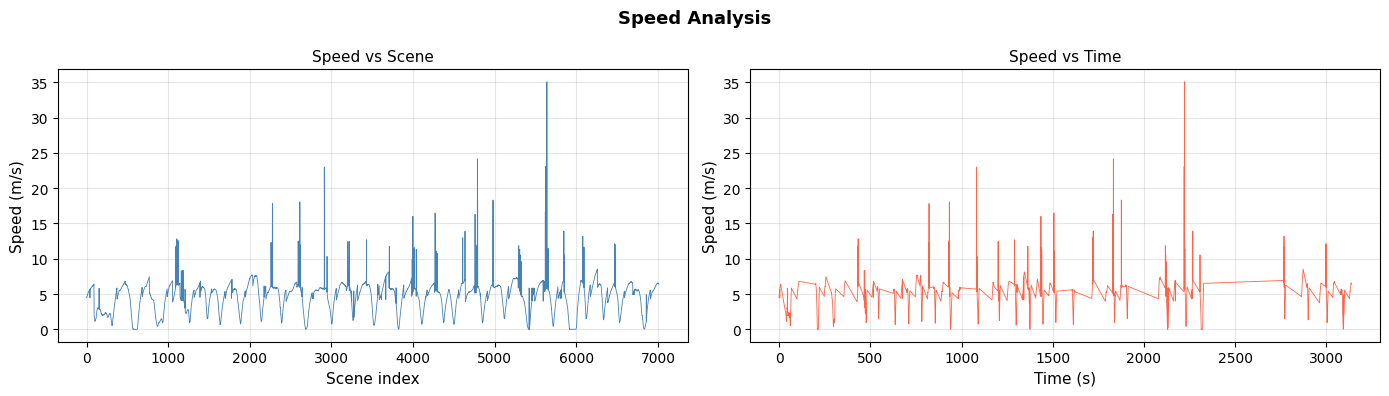

In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Speed Analysis", fontsize=13, fontweight="bold")

# 장면에 따른 속도
axes[0].plot(np.arange(N), speeds, linewidth=0.6, color="steelblue")
axes[0].set_xlabel("Scene index", fontsize=11)
axes[0].set_ylabel("Speed (m/s)", fontsize=11)
axes[0].set_title("Speed vs Scene", fontsize=11)
axes[0].grid(True, alpha=0.3)

# 시간에 따른 속도
axes[1].plot(times, speeds, linewidth=0.6, color="tomato")
axes[1].set_xlabel("Time (s)", fontsize=11)
axes[1].set_ylabel("Speed (m/s)", fontsize=11)
axes[1].set_title("Speed vs Time", fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("speed_graph.png", dpi=120, bbox_inches="tight")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ── 데이터 준비 ───────────────────────────────────────────────
diffs = np.diff(times) * 1000  # ms

# 위치 차분으로 실제 속도 계산
dx = np.diff(xs)
dy = np.diff(ys)
dt = np.diff(times)
calc_speed = np.sqrt(dx**2 + dy**2) / dt  # m/s

# 샘플링 간격 기준 분류 (정상: 70~130ms, 2배: 150~230ms)
normal_mask = (diffs >= 70)  & (diffs <= 130)
double_mask = (diffs >= 150) & (diffs <= 230)

# ── 시각화 ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Double Sampling Interval -> Double Recorded Speed Bug", fontsize=13, fontweight="bold")

# Left: recorded speed vs calculated speed
ax = axes[0]
ax.scatter(calc_speed[normal_mask], speeds[1:][normal_mask],
           s=2, alpha=0.3, color="steelblue", label="Normal (~92ms)")
ax.scatter(calc_speed[double_mask], speeds[1:][double_mask],
           s=2, alpha=0.5, color="tomato",    label="Double interval (~185ms)")
lim = max(calc_speed[normal_mask | double_mask].max(),
          speeds[1:][normal_mask | double_mask].max()) * 1.05
ax.plot([0, lim], [0, lim],     "k--", linewidth=0.8, label="y=x (ideal)")
ax.plot([0, lim], [0, lim * 2], "g--", linewidth=0.8, label="y=2x (2x error)")
ax.set_xlabel("Calculated speed (m/s)", fontsize=11)
ax.set_ylabel("Recorded speed (m/s)", fontsize=11)
ax.set_title("Recorded vs Calculated Speed", fontsize=11)
ax.legend(fontsize=8, markerscale=4)
ax.grid(True, alpha=0.3)

# Right: zoom in on scene 1085~1094
ax = axes[1]
r = slice(1085, 1095)
sc = np.arange(1085, 1095)
ax.plot(sc, speeds[r],               "o-",  color="tomato",    label="Recorded speed", markersize=5)
ax.plot(sc[:-1], calc_speed[r][:-1], "s--", color="steelblue", label="Calculated speed", markersize=5)
for i, idx in enumerate(sc[:-1]):
    ax.annotate(f"{diffs[idx]:.0f}ms", (sc[i], speeds[idx]),
                textcoords="offset points", xytext=(0, 6), fontsize=7, ha="center")
ax.set_xlabel("Scene index", fontsize=11)
ax.set_ylabel("Speed (m/s)", fontsize=11)
ax.set_title("Zoom: scene 1085~1094\n(label = sampling interval)", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("speed_sampling_bug.png", dpi=120, bbox_inches="tight")
plt.show()

# ── 수치 요약 ─────────────────────────────────────────────────
print("=== Speed statistics by sampling interval ===")
print(f"  Normal (~92ms)   recorded speed mean : {speeds[1:][normal_mask].mean():.3f} m/s")
print(f"  Double (~185ms)  recorded speed mean : {speeds[1:][double_mask].mean():.3f} m/s")
print(f"  Ratio : {speeds[1:][double_mask].mean() / speeds[1:][normal_mask].mean():.3f}  <- ~2x")
print()
print(f"  Normal (~92ms)   calculated speed mean : {calc_speed[normal_mask].mean():.3f} m/s")
print(f"  Double (~185ms)  calculated speed mean : {calc_speed[double_mask].mean():.3f} m/s")
print(f"  Ratio : {calc_speed[double_mask].mean() / calc_speed[normal_mask].mean():.3f}  <- ~1x (same in reality)")
